<a href="https://colab.research.google.com/github/m-ramaz/machine-learning-practice/blob/main/EDA/EDA_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('/content/heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


# **EDA**

In [ ]:
df.shape

(918, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [ ]:
df.describe()    #five number summary

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


# we can do EDA  and Data Cleaning simultaneously

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['HeartDisease'].value_counts()  #this shows that data is almost equally divided for training . that is good.

,count
HeartDisease,
1,508
0,410


<Axes: xlabel='HeartDisease'>

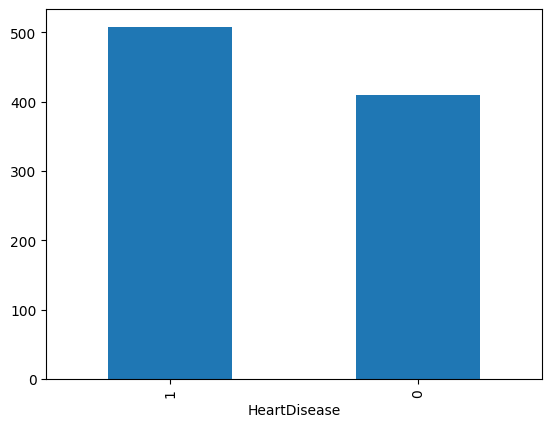

In [ ]:
df['HeartDisease'].value_counts().plot(kind='bar')

In [ ]:
df.isnull().sum()  #data me koi bhi column me null values nhi hain.

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [ ]:
def plotting(var,num):       #function create kia hai plots bnany ke lye
  plt.subplot(2,2,num)
  sns.histplot(df[var],kde=True)
  plt.tight_layout()



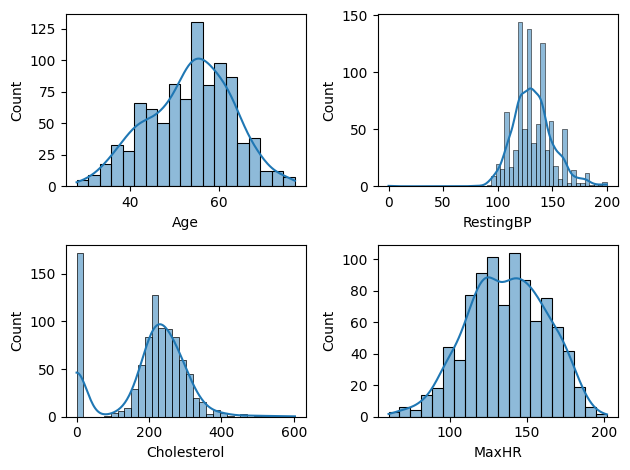

In [ ]:
plotting('Age',1)                 #functions call hu rha
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

In [ ]:
df['Cholesterol'].value_counts()   #172 values are 0 but how this is possible its wrong.

,count
Cholesterol,
0,172
254,11
220,10
223,10
204,9
...,...
353,1
278,1
157,1


In [ ]:
chol_mean=df.loc[df['Cholesterol']>0,'Cholesterol'].mean()    #df.loc[rows,col]
chol_mean


np.float64(244.6353887399464)

In [ ]:
df['Cholesterol']=df['Cholesterol'].replace(0,chol_mean)


In [ ]:
df['Cholesterol'].value_counts()    #now these 172 rows are replaced with mean.

,count
Cholesterol,
244.635389,172
254.000000,11
220.000000,10
223.000000,10
204.000000,9
...,...
353.000000,1
278.000000,1
157.000000,1


In [ ]:
df['Cholesterol']=df['Cholesterol'].round(2)
df['Cholesterol'].value_counts()


,count
Cholesterol,
244.64,172
254.00,11
220.00,10
223.00,10
204.00,9
...,...
353.00,1
278.00,1
157.00,1


In [ ]:
df['RestingBP'].value_counts()

,count
RestingBP,
120,132
130,118
140,107
110,58
150,55
...,...
101,1
117,1
192,1


In [ ]:
restingbp_mean=df.loc[df['RestingBP']>0,'RestingBP'].mean()
restingbp_mean

np.float64(132.54089422028352)

In [ ]:
df['RestingBP']=df['RestingBP'].replace(0,restingbp_mean)
df['RestingBP'].value_counts()

,count
RestingBP,
120.0,132
130.0,118
140.0,107
110.0,58
150.0,55
...,...
101.0,1
117.0,1
192.0,1


<Axes: xlabel='RestingBP', ylabel='Count'>

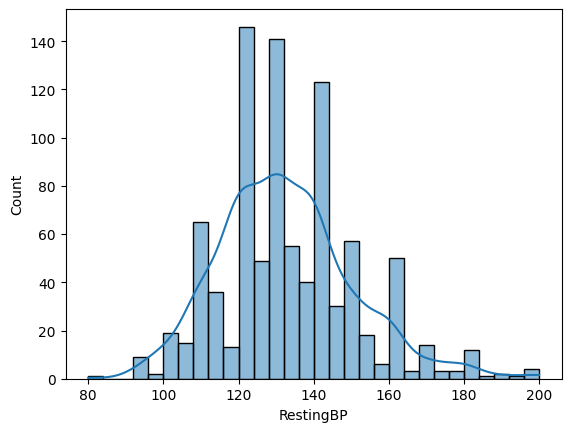

In [ ]:
sns.histplot(df['RestingBP'],kde=True)

<Axes: xlabel='RestingBP'>

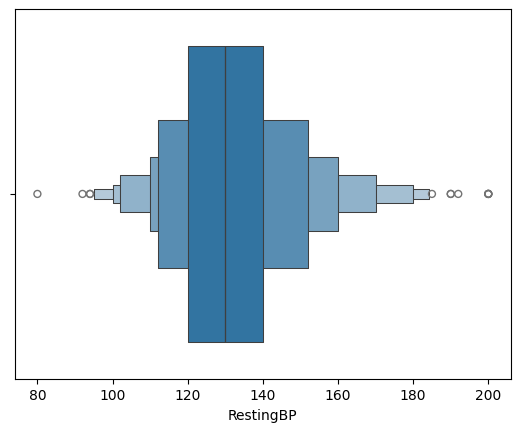

In [ ]:
sns.boxenplot(x=df['RestingBP'])

# **Graphs for categorical columns -> best are count /bar plot**

In [ ]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

<Axes: xlabel='ExerciseAngina', ylabel='count'>

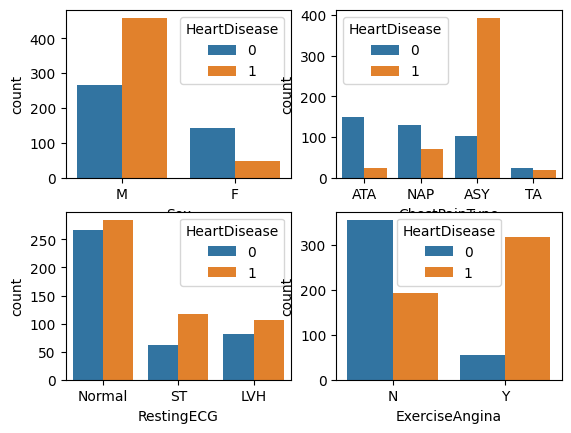

In [ ]:
plt.subplot(2,2,1)
sns.countplot(x=df['Sex'],hue=df["HeartDisease"])
plt.subplot(2,2,2)
sns.countplot(x=df['ChestPainType'],hue=df["HeartDisease"])
plt.subplot(2,2,3)
sns.countplot(x=df['RestingECG'],hue=df["HeartDisease"])
plt.subplot(2,2,4)
sns.countplot(x=df['ExerciseAngina'],hue=df["HeartDisease"])

<Axes: xlabel='FastingBS', ylabel='count'>

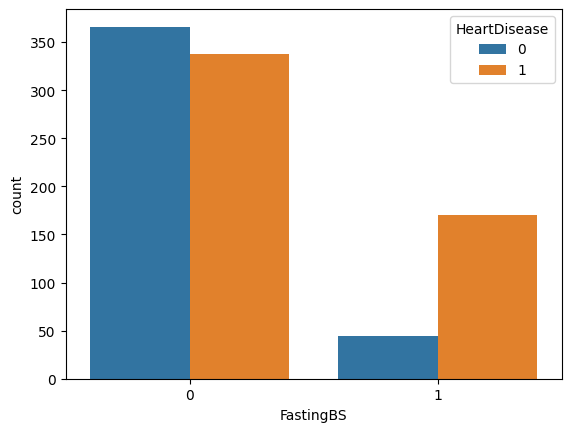

In [ ]:
sns.countplot(x=df['FastingBS'],hue=df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

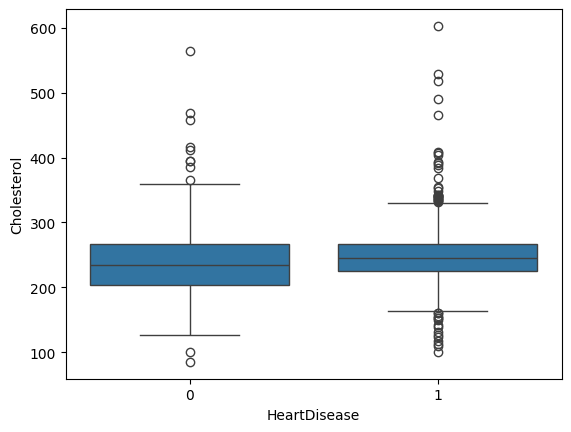

In [ ]:
sns.boxplot(x=df['HeartDisease'],y=df['Cholesterol'])

<Axes: >

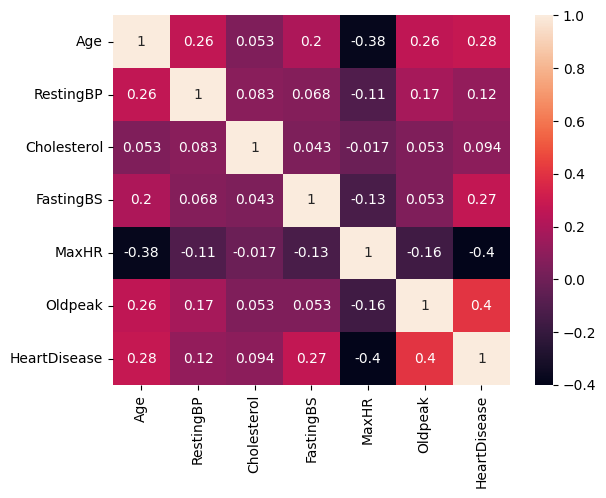

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)    #heatmap(matrix chahye )   aur df.corr() matrix return krta

# **Data PreProcessing and Cleaning**

In [ ]:
df_encode=pd.get_dummies(df,drop_first=True)   #one hot encoding pory data frame pr apply ki
df_encode=df_encode.astype(int)            #tru aur false ki value ko 1 aur 0 me krny ke lye pory dataframe pr apply kia

In [ ]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df_encode[['Age','RestingBP','Cholesterol','MaxHR']]=scaler.fit_transform(df_encode[['Age','RestingBP','Cholesterol','MaxHR']])

In [ ]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,0,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,1,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,0,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,1,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253622,0.365619,0,-0.188999,1,1,1,0,0,1,1,0,0,1,0
914,1.536902,0.637353,-0.966725,1,0.164684,3,1,1,0,0,0,1,0,0,1,0
915,0.370100,-0.141284,-2.130180,0,-0.857069,1,1,1,0,0,0,1,0,1,1,0
916,0.370100,-0.141284,-0.159813,0,1.461525,0,1,0,1,0,0,0,0,0,1,0


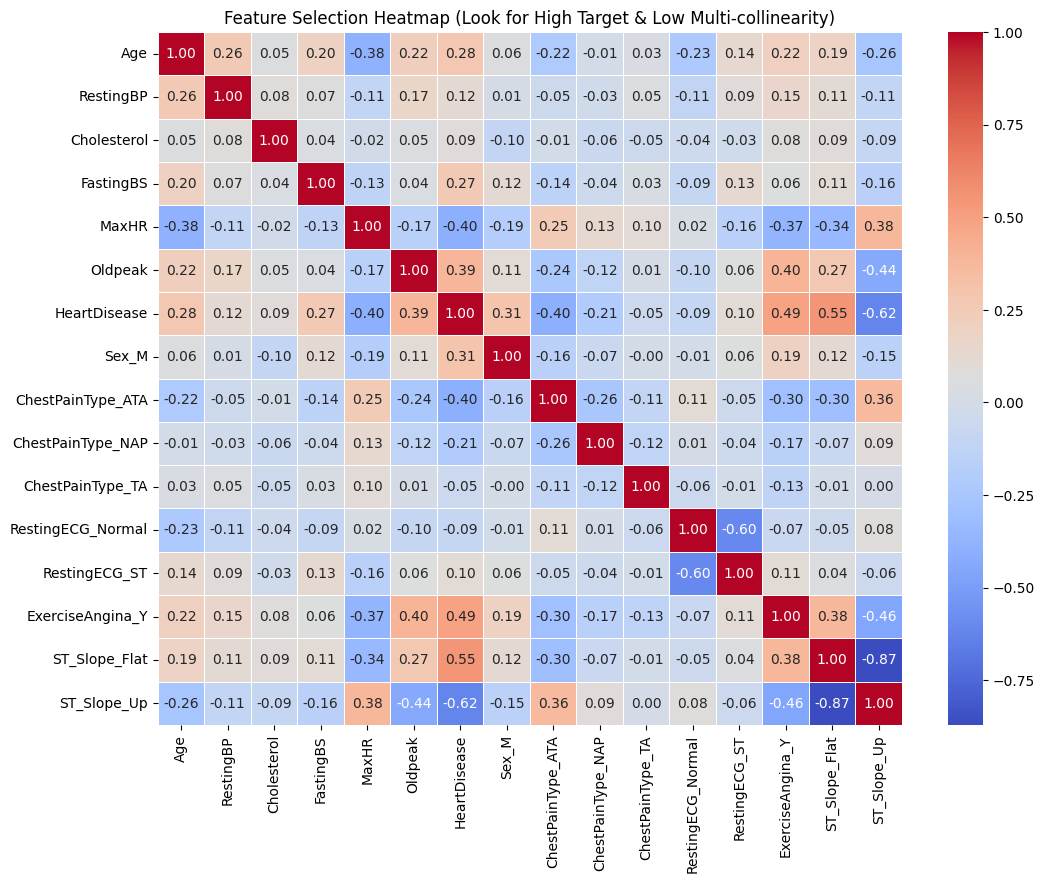

--- 🎯 Feature Selection Report ---
⚠️ Yeh columns Multicollinearity phela rahe hain, inhe DROP kr dena behtar hai: ['ST_Slope_Up']


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Correlation Matrix nikalen
corr_matrix = df_encode.corr().abs() # .abs() se negative relation bhi positive ho kar asaani se dikhta hai

# 2. Khoobsurat Visual Heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(df_encode.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Selection Heatmap (Look for High Target & Low Multi-collinearity)')
plt.show()

# 3. AUTOMATION: Faltu (High Correlated) Features ko automatically pakadna
# Upper triangle matrix banayen taaki duplicate pairs na aayen
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Agar do features ka aapas me relation 0.75 se upar hai, toh ek ko select karein
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.75) and column != 'charges']

print("--- 🎯 Feature Selection Report ---")
if len(to_drop) > 0:
    print(f"⚠️ Yeh columns Multicollinearity phela rahe hain, inhe DROP kr dena behtar hai: {to_drop}")
else:
    print("✅ Perfect! Aapke features ke beech koi khatarnak Multicollinearity nahi hai.")


In [ ]:
df_encode=df_encode.drop(columns=['ST_Slope_Up'])
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat
0,-1.433140,0.414885,0.834754,0,1.382928,0,0,1,1,0,0,1,0,0,0
1,-0.478484,1.527224,-1.210675,0,0.754157,1,1,0,0,1,0,1,0,0,1
2,-1.751359,-0.141284,0.722161,0,-1.525138,0,0,1,1,0,0,0,1,0,0
3,-0.584556,0.303651,-0.572651,0,-1.132156,1,1,0,0,0,0,1,0,1,1
4,0.051881,0.971054,-0.929194,0,-0.581981,0,0,1,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253622,0.365619,0,-0.188999,1,1,1,0,0,1,1,0,0,1
914,1.536902,0.637353,-0.966725,1,0.164684,3,1,1,0,0,0,1,0,0,1
915,0.370100,-0.141284,-2.130180,0,-0.857069,1,1,1,0,0,0,1,0,1,1
916,0.370100,-0.141284,-0.159813,0,1.461525,0,1,0,1,0,0,0,0,0,1


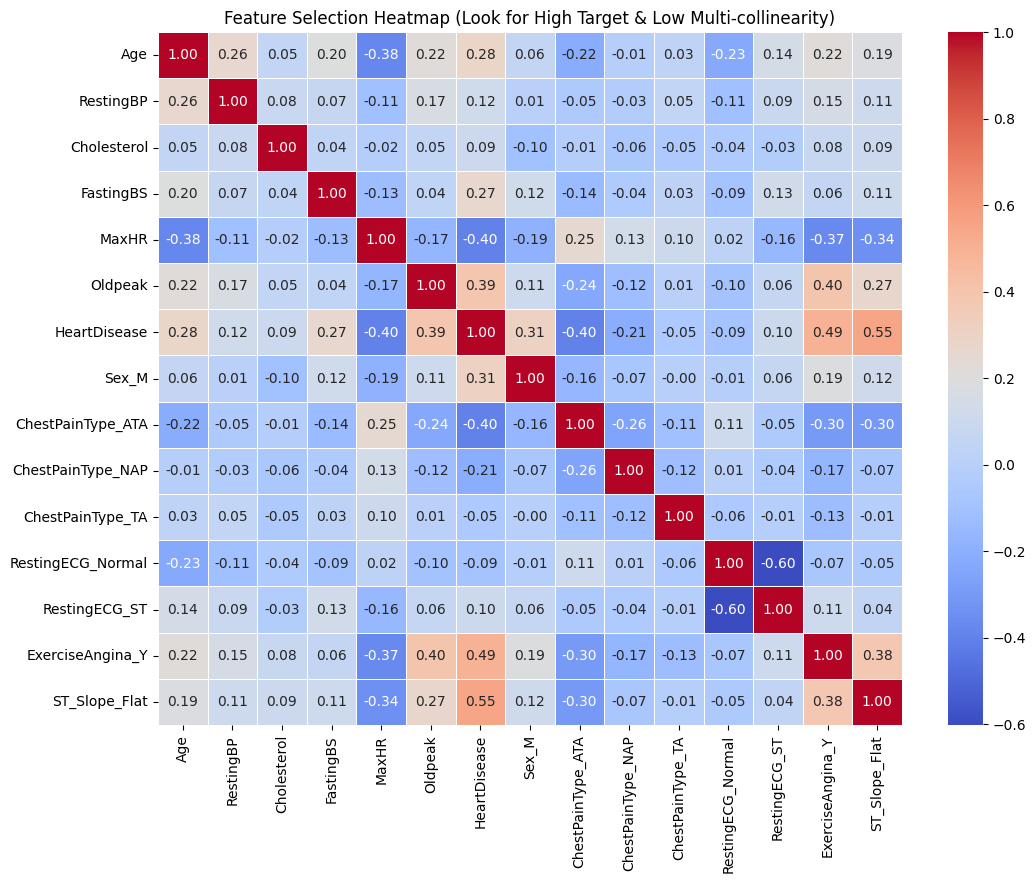

--- 🎯 Feature Selection Report ---
✅ Perfect! Aapke features ke beech koi khatarnak Multicollinearity nahi hai.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Correlation Matrix nikalen
corr_matrix = df_encode.corr().abs() # .abs() se negative relation bhi positive ho kar asaani se dikhta hai

# 2. Khoobsurat Visual Heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(df_encode.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Selection Heatmap (Look for High Target & Low Multi-collinearity)')
plt.show()

# 3. AUTOMATION: Faltu (High Correlated) Features ko automatically pakadna
# Upper triangle matrix banayen taaki duplicate pairs na aayen
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Agar do features ka aapas me relation 0.75 se upar hai, toh ek ko select karein
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.75) and column != 'charges']

print("--- 🎯 Feature Selection Report ---")
if len(to_drop) > 0:
    print(f"⚠️ Yeh columns Multicollinearity phela rahe hain, inhe DROP kr dena behtar hai: {to_drop}")
else:
    print("✅ Perfect! Aapke features ke beech koi khatarnak Multicollinearity nahi hai.")
